In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sn
import joblib

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report


In [2]:
iris = load_iris()


In [3]:
df = pd.DataFrame(iris.data, columns=iris.feature_names)


In [4]:
df['target'] = iris.target

print(df.head())

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   target  
0       0  
1       0  
2       0  
3       0  
4       0  


In [5]:
X = df.drop('target', axis='columns')
y = df.target

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


In [7]:

model_default = RandomForestClassifier(
    n_estimators=10,
    random_state=42
)

model_default.fit(X_train, y_train)

default_score = model_default.score(X_test, y_test)

print("\nAccuracy with default n_estimators=10 :", default_score)



Accuracy with default n_estimators=10 : 1.0


In [8]:
scores = {}

for n in [5, 10, 20, 50, 100, 200]:
    
    model = RandomForestClassifier(
        n_estimators=n,
        random_state=42
    )
    
    model.fit(X_train, y_train)
    
    score = model.score(X_test, y_test)
    
    scores[n] = score
    
    print(f"Accuracy with {n} trees : {score}")

Accuracy with 5 trees : 0.9666666666666667
Accuracy with 10 trees : 1.0
Accuracy with 20 trees : 1.0
Accuracy with 50 trees : 1.0
Accuracy with 100 trees : 1.0
Accuracy with 200 trees : 1.0


In [9]:
best_n = max(scores, key=scores.get)

best_score = scores[best_n]

print("\nBest Number of Trees :", best_n)
print("Best Accuracy Score :", best_score)



Best Number of Trees : 10
Best Accuracy Score : 1.0


In [10]:
best_model = RandomForestClassifier(
    n_estimators=best_n,
    random_state=42
)

best_model.fit(X_train, y_train)


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",10
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(

In [11]:
y_predicted = best_model.predict(X_test)


In [12]:

print("\nClassification Report:\n")

print(classification_report(y_test, y_predicted))


Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



In [13]:
cm = confusion_matrix(y_test, y_predicted)

print("\nConfusion Matrix:\n")
print(cm)



Confusion Matrix:

[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


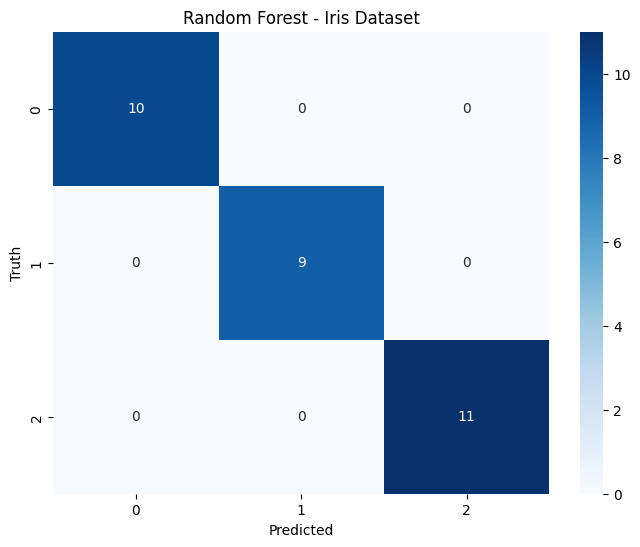

In [14]:

plt.figure(figsize=(8,6))

sn.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel('Predicted')
plt.ylabel('Truth')
plt.title('Random Forest - Iris Dataset')

plt.show()

In [15]:
joblib.dump(best_model, 'random_forest_iris_model.pkl')

print("\nModel saved successfully as random_forest_iris_model.pkl")


Model saved successfully as random_forest_iris_model.pkl


In [16]:
loaded_model = joblib.load('random_forest_iris_model.pkl')


In [17]:
sample_prediction = loaded_model.predict([X_test.iloc[0]])

print("\nSample Prediction :", sample_prediction[0])
print("Actual Value :", y_test.iloc[0])


Sample Prediction : 1
Actual Value : 1


/home/rithik-ca/Documents/Learning and Projects/MLops_Learning/venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
